In [497]:
import numpy as np
import matplotlib.pyplot as plt
import random
# %autoreload
from evoscape.landscapes import Landscape, Somitogenesis_Landscape
from evoscape.modules import Node, UnstableNode, Center, NegCenter
from evoscape.landscape_visuals import *
import evoscape.morphogen_regimes as mr


from evoscape.module_helper_functions import landscape_from_timecode, modules_from_txt, invert_landscape
from PIL import Image


%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [633]:
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 200})
plt.rcParams.update({'font.size': 15})  
plt.rcParams['axes.grid'] = False

In [499]:
def figure_from_timecode(timecode, data_dir, name='landscape_1'):
    filename = data_dir + timecode + '/result_' + name + '.png'
    image = Image.open(filename)
    display(image)

In [500]:
time_pars = (0., 50., 201)

morphogen_times = (0.,)
gen = 49

fitness_pars = {
    'ncells': 100,
    'time_pars': time_pars,
    'init_state': (0., 0.),
    't0_shift': 0.25,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.0,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.1,
    't_stable': 5,  # how many timepoints should be at steady state
    'ndt': 50,
    'n_boundaries': 10,
}

fitness_pars_50 = {
    'ncells': 50,
    'time_pars': time_pars,
    'init_state': (0., 0.),
    't0_shift': 0.5,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.0,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.1,
    't_stable': 5,  # how many timepoints should be at steady state
    'ndt': 50,
    'n_boundaries': 10,
}

landscape_pars = {
    'A0': 0.05,
    'init_cond': (0., 0.),
    'regime': mr.mr_sigmoid,
    'n_regimes': 2,
    'morphogen_times': morphogen_times,
    'used_fp_types': (Node, UnstableNode, Center, NegCenter),
    'immutable_pars_list': ['tau',],
}


(30,)
17
(30,)
27
(30,)
19


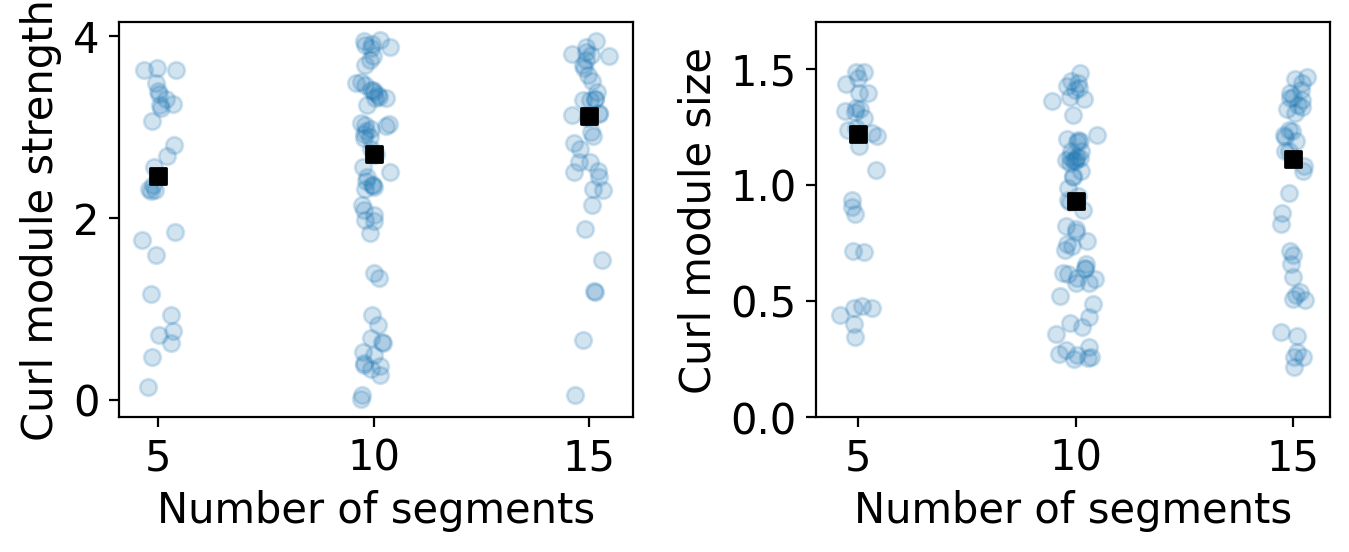

In [502]:
fig, (ax0, ax1) = plt.subplots(1,2, figsize=[7,3])

n = (5, 10, 15)

times = np.linspace(*time_pars)

for i, data_dir in enumerate([data_dir_5, data_dir_10, data_dir_15]):
    file_name = data_dir + 'optimization_log.csv'
    log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Fitness'], dtype=None, encoding='utf-8')
    print(log.shape)
    fitness_threshold = -1

    timecodes = log['Timecode'][log['Fitness'] > fitness_threshold]
    fitnesses = log['Fitness'][log['Fitness'] > fitness_threshold]
    n_landscapes = len(timecodes)
    print(n_landscapes)
    amps = []
    sums = []
    sizes = []
    curls = []

    # idx = stable_osc[str(n[i])]
    # for j in idx:
    #     timecode = timecodes[j]
    for timecode in timecodes:
    #     max_amp = 0
        landscape = landscape_from_timecode(Somitogenesis_Landscape, timecode, data_dir, gen, landscape_pars)
        # landscape.morphogen_times = (20.,)
        # landscape.init_cells(1, (0., 0.,), 0.)
        # traj, states = landscape.run_cells(*time_pars, noise=0., ndt=fitness_pars['ndt'], get_states=False, frozen=True, t_freeze=0.)
        # ax[i].plot(times, traj[0, 0, :], alpha=0.2, lw=2, c ='tab:blue')

        for mod in landscape.module_list:
            if mod.__class__.__name__ == 'Center' or mod.__class__.__name__ == 'NegCenter':
                amps.append(mod.a[0])
                sizes.append(mod.s[0])
                ax0.scatter(n[i]+0.2*np.random.randn(), mod.a[0], c='tab:blue', alpha=0.2)
                ax1.scatter(n[i]+0.2*np.random.randn(), mod.s[0], c='tab:blue', alpha=0.2)
    amps = np.array(amps)
    # ax0.errorbar(n[i], np.median(amps), yerr=np.std(amps), c='k')
    ax0.scatter(n[i], np.median(amps), c='k', marker='s')
    # ax0.boxplot(amps, positions=(n[i],), widths=2.)
    # ax1.errorbar(n[i], np.median(sizes), yerr=np.std(sizes), c='k')
    ax1.scatter(n[i], np.median(sizes), c='k', marker='s')
    # ax1.boxplot(sizes, positions=(n[i],), widths=2.)

    ax1.set_ylim((0, 1.7))
    ax0.set_ylabel('Curl module strength')
    ax1.set_ylabel('Curl module size')
    ax0.set_xlabel('Number of segments')
    ax1.set_xlabel('Number of segments')
for axi in ax:
    axi.set_ylim((-3,3))
plt.tight_layout()
plt.show()

In [503]:

def estimate_period_fft(t, y):
    dt = t[1] - t[0]
    N = len(t)
    Y = np.fft.rfft(y - np.mean(y))
    freqs = np.fft.rfftfreq(N, d=dt)
    idx = np.argmax(np.abs(Y[1:])) + 1
    f_peak = freqs[idx]
    T_peak = 1 / f_peak
    return T_peak

5
(30,)
17
10
(30,)
27
15
(30,)
19


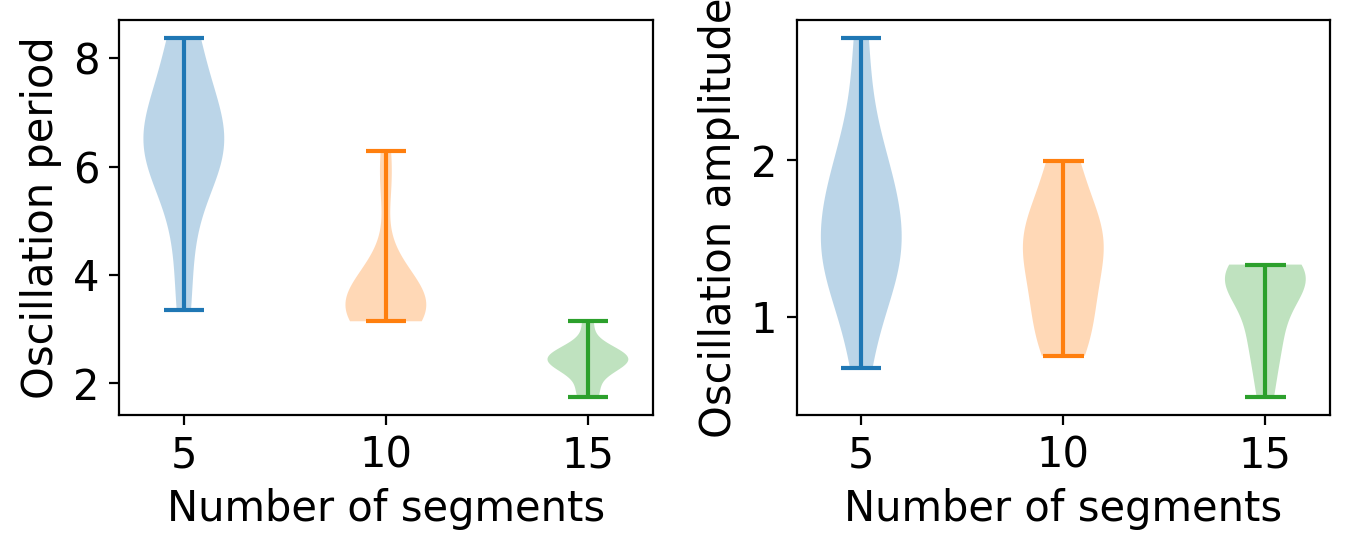

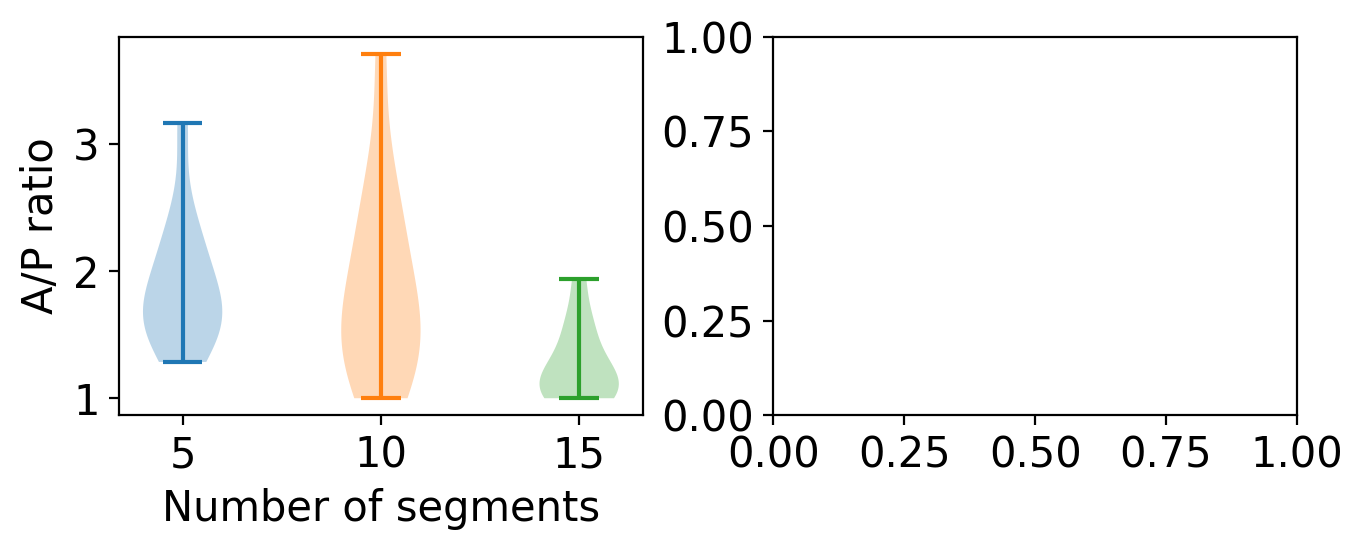

In [495]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[7, 3])
fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=[7, 3])

# fig2, ax = plt.subplots(3, 1, figsize=[8, 7], sharex=True)

n = (5, 10, 15)

stable_osc = {'5': [0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16],
       '10': [4, 5, 6, 8, 10, 11, 12, 13, 15, 16, 17, 20, 23, 24, 26],
       '15': [1, 2, 3, 8, 10, 11, 13, 15, 16, 17, 18]}



times = np.linspace(*time_pars)

for i, data_dir in enumerate([data_dir_5, data_dir_10, data_dir_15]):
    print(n[i])
    file_name = data_dir + 'optimization_log.csv'
    log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Fitness'], dtype=None,
                        encoding='utf-8')
    print(log.shape)
    fitness_threshold = -1

    timecodes = log['Timecode'][log['Fitness'] > fitness_threshold]
    fitnesses = log['Fitness'][log['Fitness'] > fitness_threshold]
    n_landscapes = len(timecodes)
    print(n_landscapes)

    amps = []
    periods = []
    ratios = []
    lows = []
    highs = []


    idx = stable_osc[str(n[i])]
    for j in idx:
        timecode = timecodes[j]
    # for j, timecode in enumerate(timecodes):

        # n_curls = 0
        # sum_amps = 0
        landscape = landscape_from_timecode(Somitogenesis_Landscape, timecode, data_dir, gen, landscape_pars)
        landscape.morphogen_times = (25.,)
        landscape.init_cells(1, (0., 0.,), 0.)

        frozen_traj, states = landscape.run_cells(*time_pars, noise=0., ndt=fitness_pars['ndt'], get_states=False, frozen=True,
                                           t_freeze=0.)
        limits = (np.max(frozen_traj[0, 0, :]), np.min(frozen_traj[0, 0, :]))
        center = (limits[0] + limits[1]) / 2.
        amplitude = (limits[0] - limits[1])/2.
        T = estimate_period_fft(times, frozen_traj[0,0,:])

        # Oscillator characteristics
        periods.append(T)
        amps.append(amplitude)

        traj, states = landscape.run_cells(*time_pars, noise=0., ndt=fitness_pars['ndt'], get_states=False)

        landscape.get_fitness(fitness_pars)
        kymo = landscape.result[0]
        pattern = kymo[:, -1]
        high = np.max(pattern) - center
        low = np.min(pattern) - center
        lows.append(low/amplitude)
        highs.append(high/amplitude)

        # Ratio of AP polarity
        rostr = np.sum(pattern>1.)
        caud = np.sum(pattern< -1.)
        ratio = rostr/caud
        if ratio < 1:
            ratio = 1/ratio
        ratios.append(ratio)

        # fig = plt.figure(figsize=(3,2))
        # plt.plot(times, frozen_traj[0, 0, :]-center, alpha=0.5, lw=2, c='tab:green')
        # plt.plot(times, traj[0, 0, :]-center, alpha=0.5, lw=2, c='tab:blue')
        # plt.vlines(T, -3, 3)
        # plt.vlines(2*T, -3, 3)
        # plt.title(str(j)+', '+str(T))
        # plt.show()

        # ax0.scatter(n[i]+0.2*np.random.randn(), T, c='tab:blue', alpha=0.2)
        # ax1.scatter(n[i]+0.2*np.random.randn(), amplitude, c='tab:blue', alpha=0.2)
        # ax2.scatter(n[i]+0.2*np.random.randn(), ratio, c='tab:blue', alpha=0.2)
        # ax3.scatter(n[i]+0.2*np.random.randn(), low/amplitude, c='tab:blue', alpha=0.2)
        # ax3.scatter(n[i]+0.2*np.random.randn(), high/amplitude, c='tab:blue', alpha=0.2)
    ax0.violinplot(periods, positions=(n[i],), widths=2.,)
    ax2.violinplot(ratios, positions=(n[i],), widths=2.,)

    # ax0.scatter(n[i], np.median(periods), c='k', marker='s')
    # ax1.scatter(n[i], np.median(amps), c='k', marker='s')
    ax1.violinplot(amps, positions=(n[i],), widths=2.)
ax0.set_ylabel('Oscillation period')
ax1.set_ylabel('Oscillation amplitude')
ax0.set_xlabel('Number of segments')
ax1.set_xlabel('Number of segments')

ax2.set_ylabel('A/P ratio')
# ax3.set_ylabel('A/P state locations')


ax2.set_xlabel('Number of segments')
# ax3.set_xlabel('Number of segments')
fig.tight_layout()
fig2.tight_layout()
# for axi in ax:
#     axi.set_ylim((-3, 3))
plt.show()

In [645]:
data_dir_5 = '../alfyn_results_rev/saved_files_somites_5/Somitogenesis_Landscape/'
data_dir_10 = '../alfyn_results_rev/saved_files_somites_10/Somitogenesis_Landscape/'
data_dir_15 = '../alfyn_results_rev/saved_files_somites_15/Somitogenesis_Landscape/'

data_dir = data_dir_5
file_name = data_dir + 'optimization_log.csv'


log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Fitness'], dtype=None, encoding='utf-8')
print(log.shape)

fitness_threshold = -1

timecodes = log['Timecode'][log['Fitness'] > fitness_threshold]
fitnesses = log['Fitness'][log['Fitness'] > fitness_threshold]
n_landscapes = len(timecodes)
print(len(timecodes))

(30,)
17


Landscape with modules:
Node: x=1.8289323210737845; y=-1.6918555365953893; a=[1.98130228,1.07352710]; s=[1.42065429,0.73513023]; tau=5.0,
Node: x=-1.5243153828897045; y=1.1149385636740177; a=[1.82028452,0.92223154]; s=[0.66095924,1.46352099]; tau=5.0,
Node: x=1.9128159682071617; y=1.2809462922596682; a=[0.03572684,1.01853552]; s=[0.71290601,0.22409911]; tau=5.0,
Center: x=1.0850948147962391; y=0.5094755844515229; a=[3.65151978,2.52571642]; s=[1.33092695,0.85234310]; tau=5.0,
UnstableNode: x=0.6962440152236726; y=0.10348904660989788; a=[2.50243337,0.18655363]; s=[0.90372023,0.85533616]; tau=5.0,
UnstableNode: x=0.6549462934497661; y=-1.0172403556301743; a=[0.68627718,2.72864837]; s=[1.11569705,0.79436794]; tau=5.0


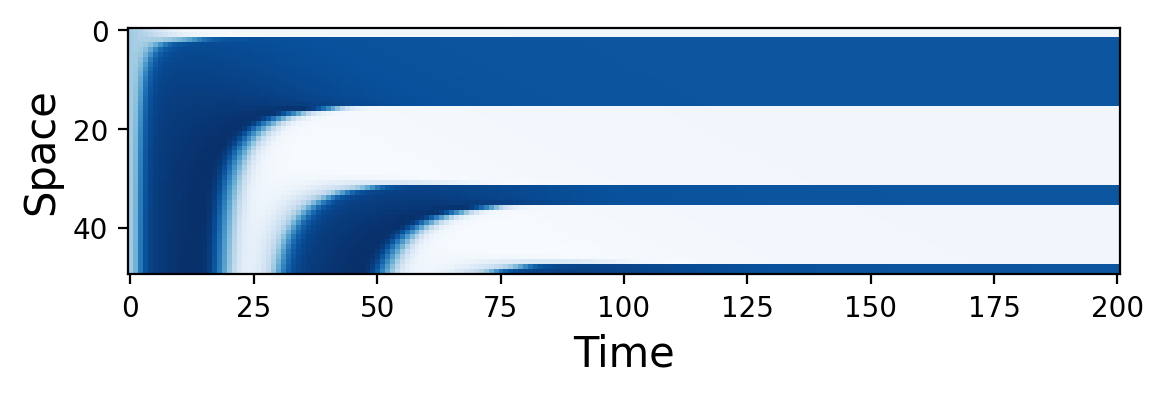

0.0


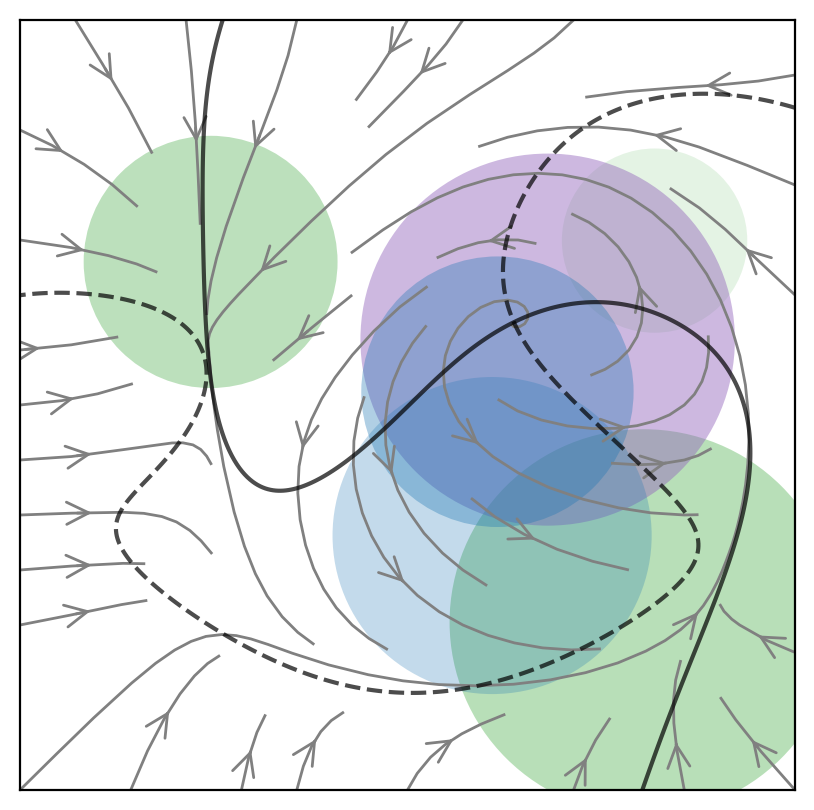

0.5


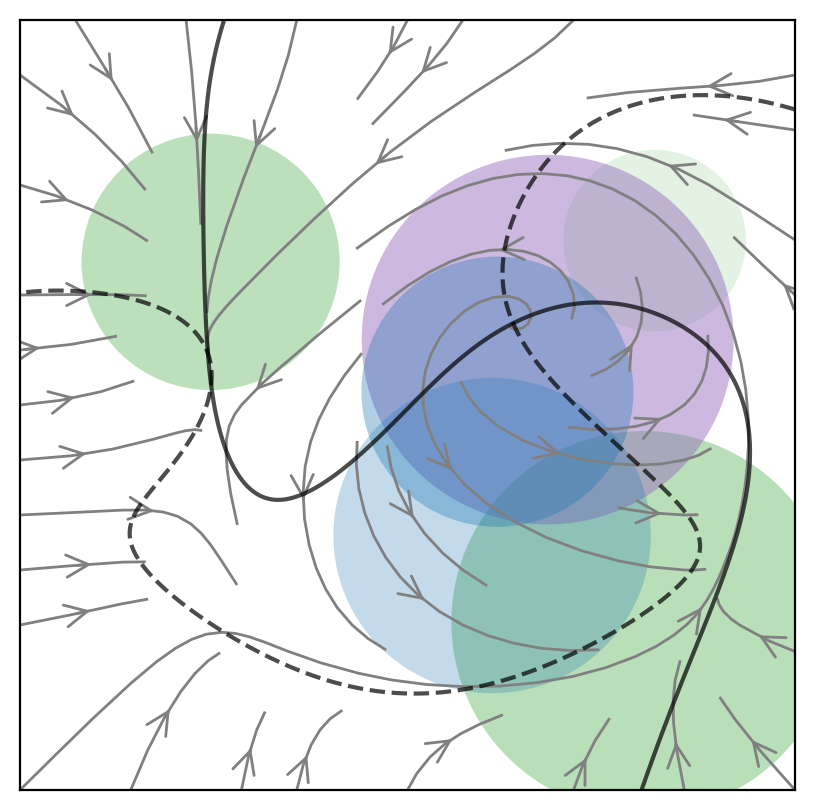

1.0


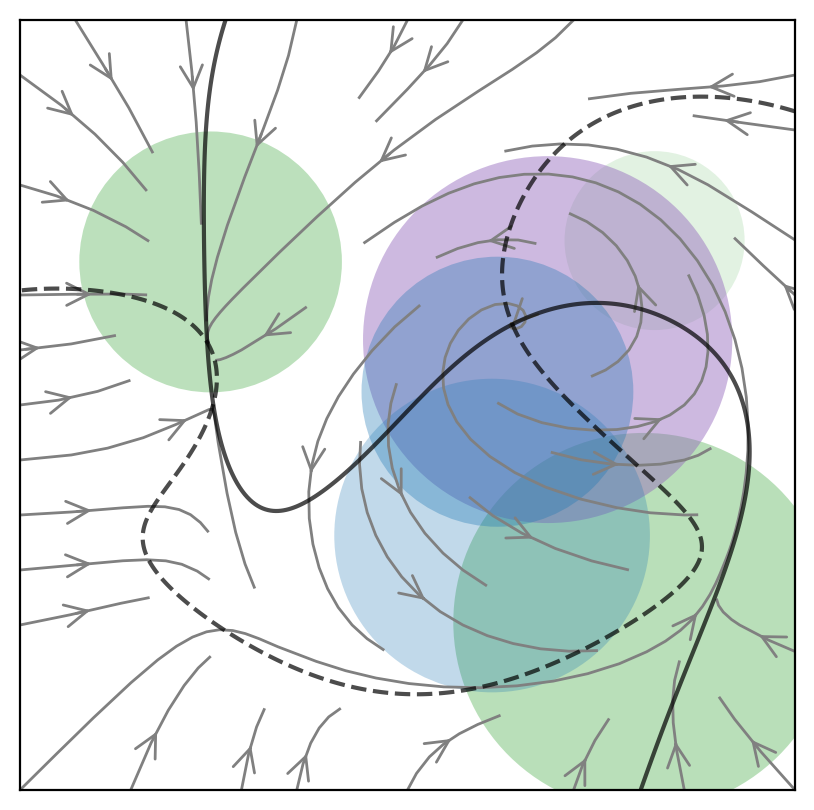

1.5


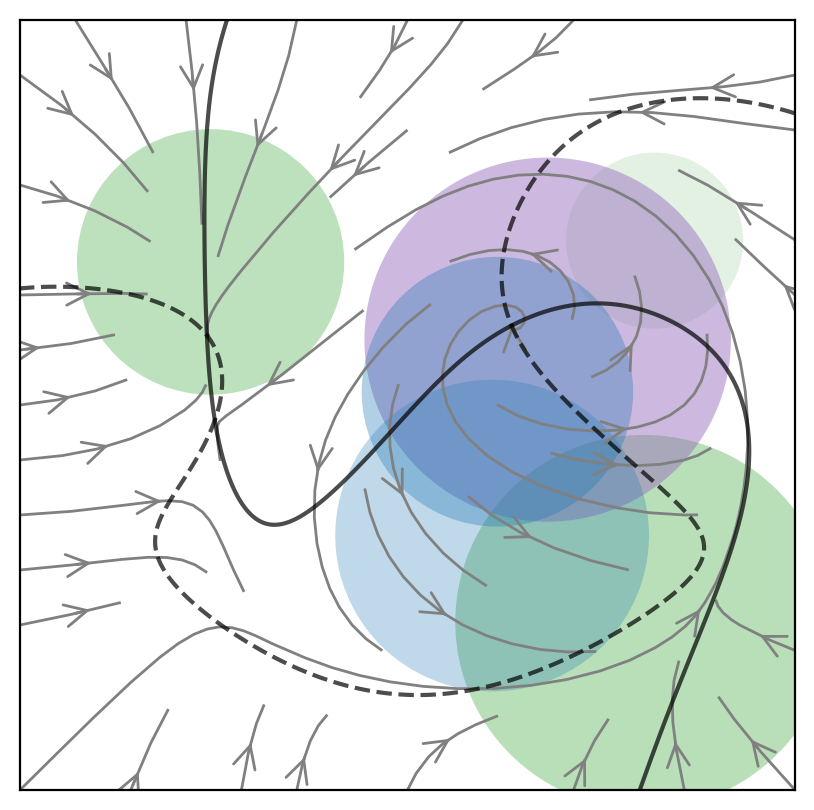

2.0


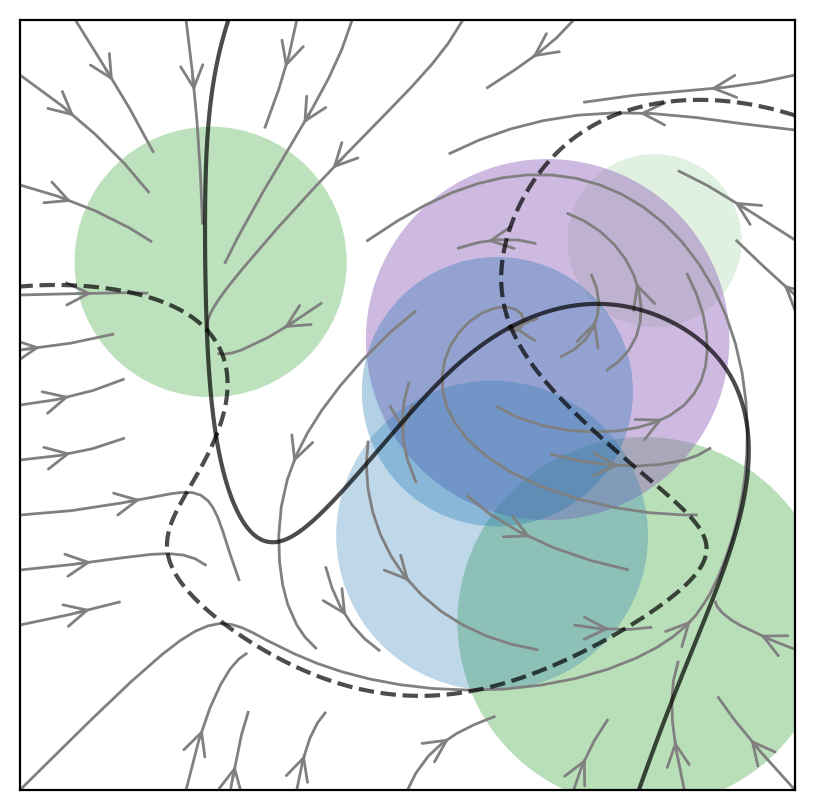

2.5


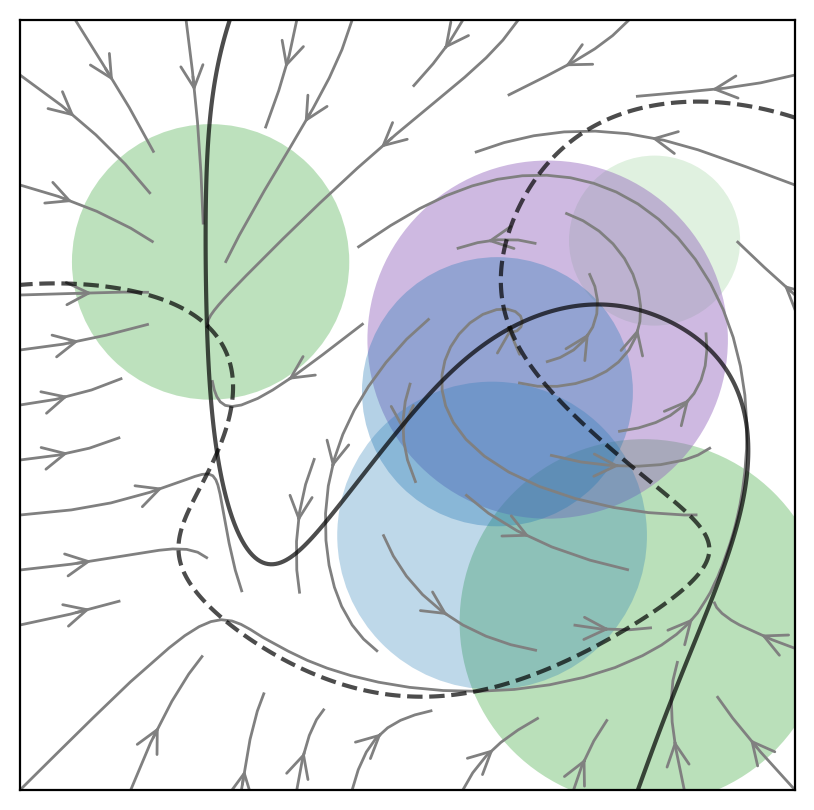

3.0


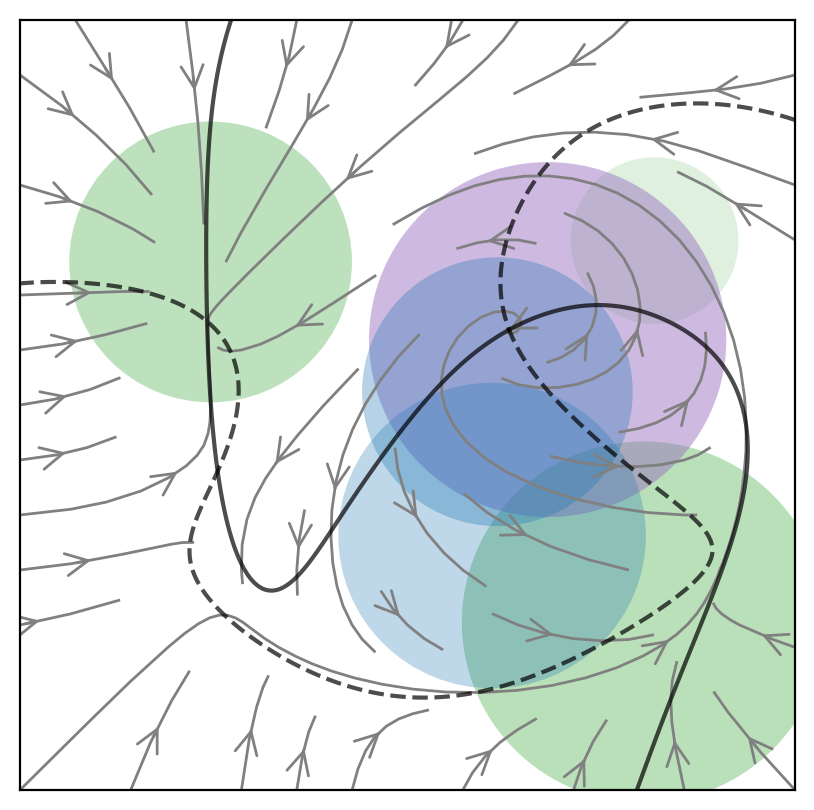

3.5


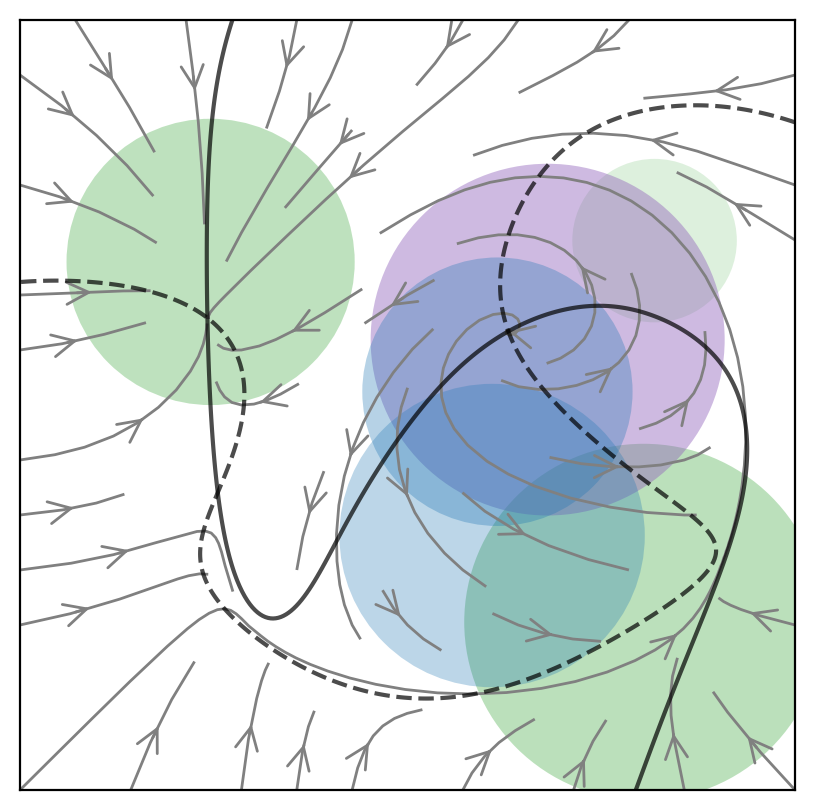

4.0


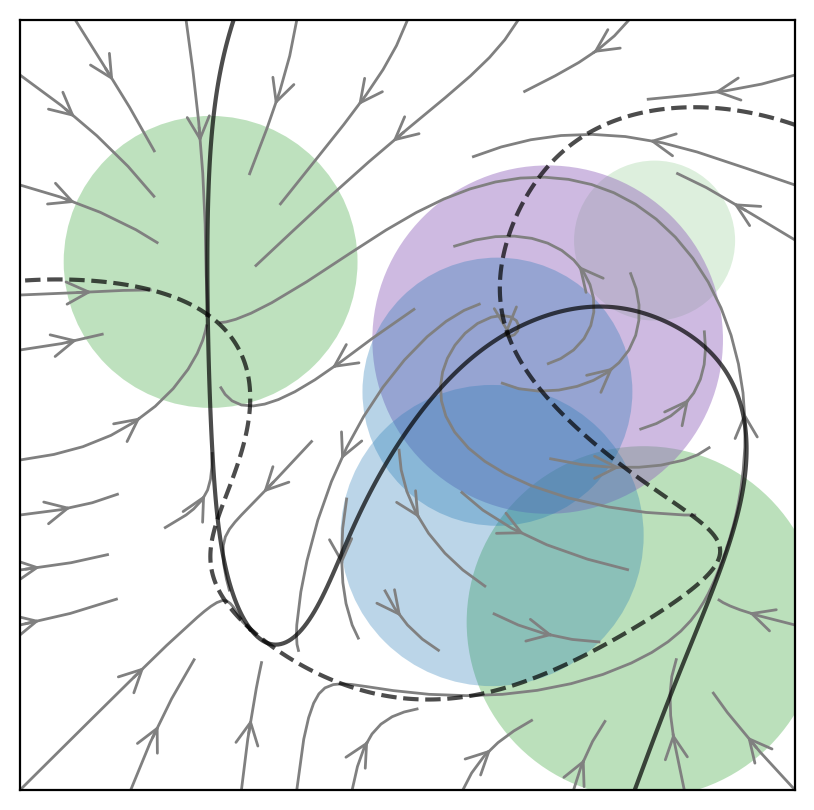

4.5


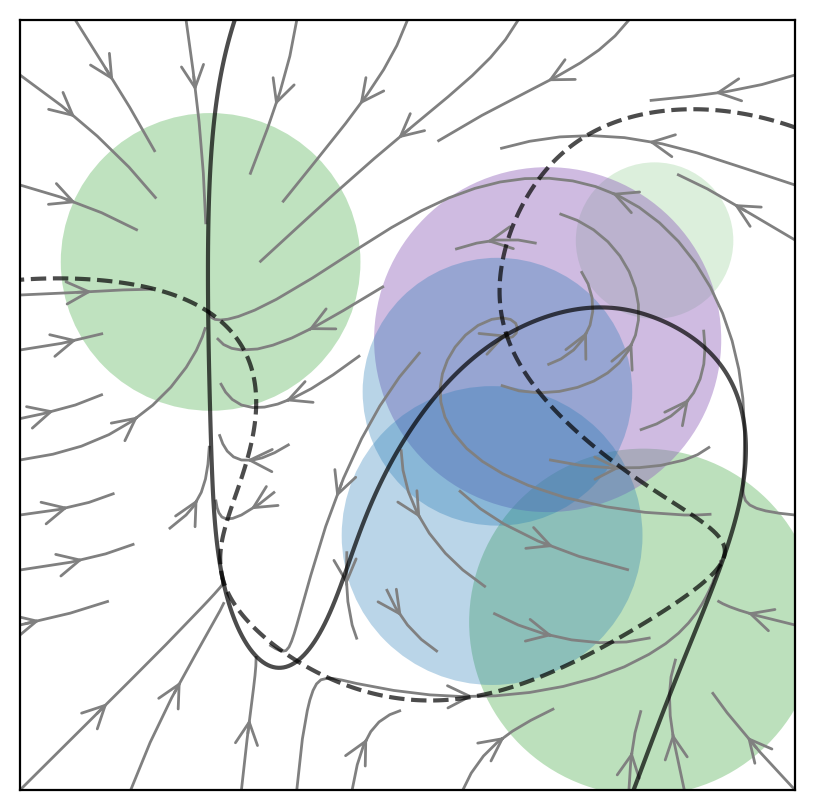

5.0


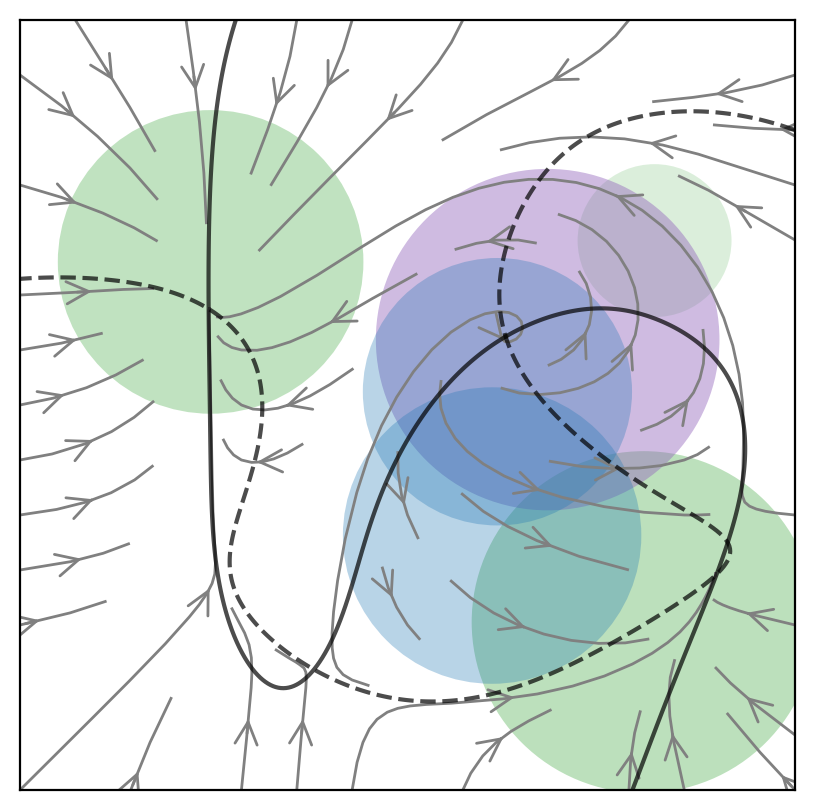

5.5


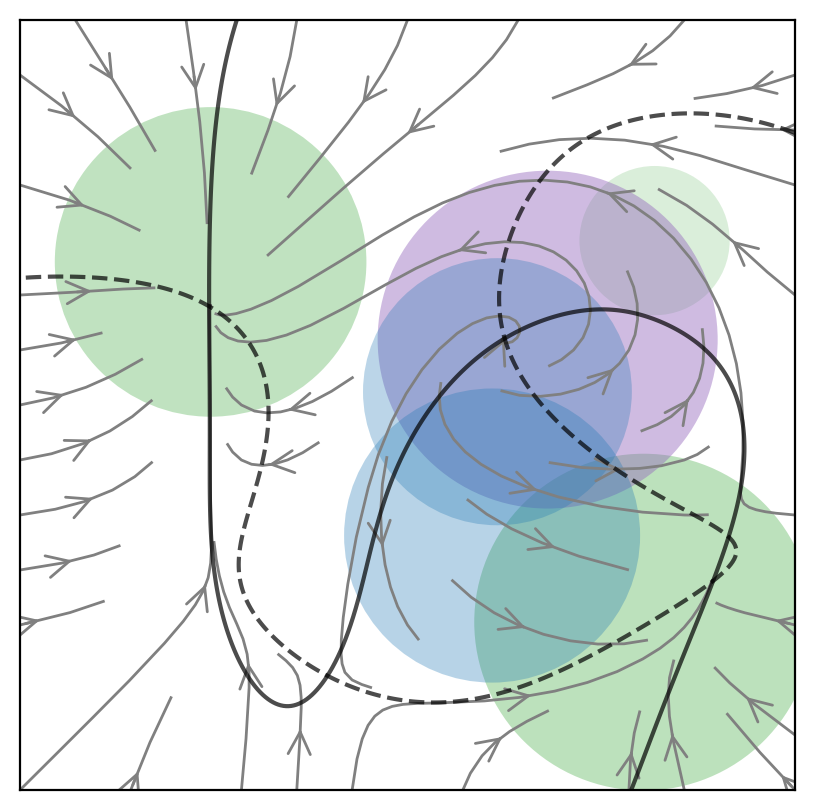

6.0


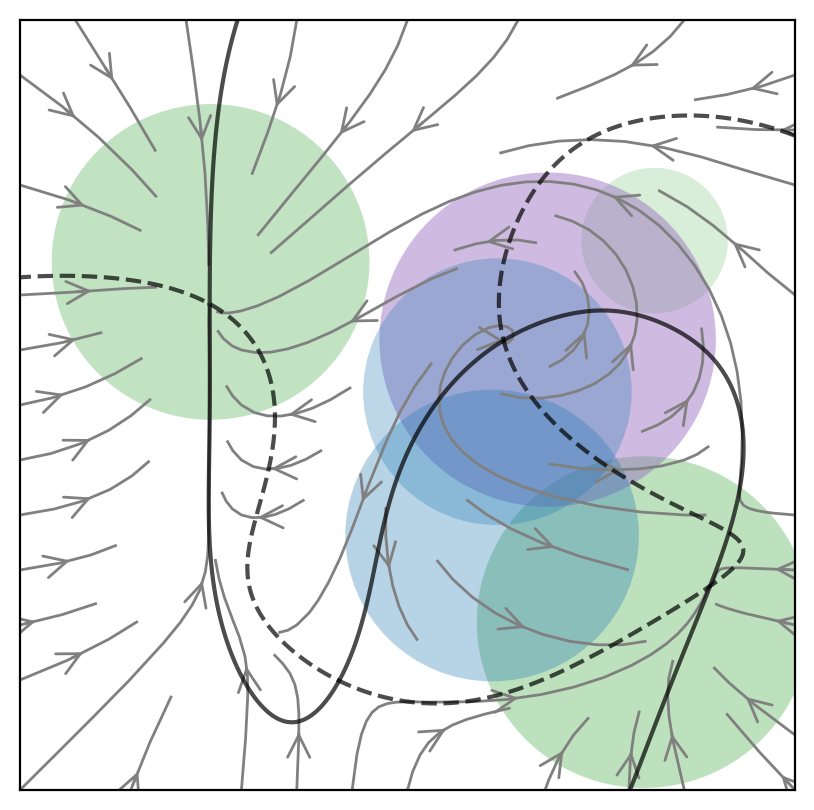

6.5


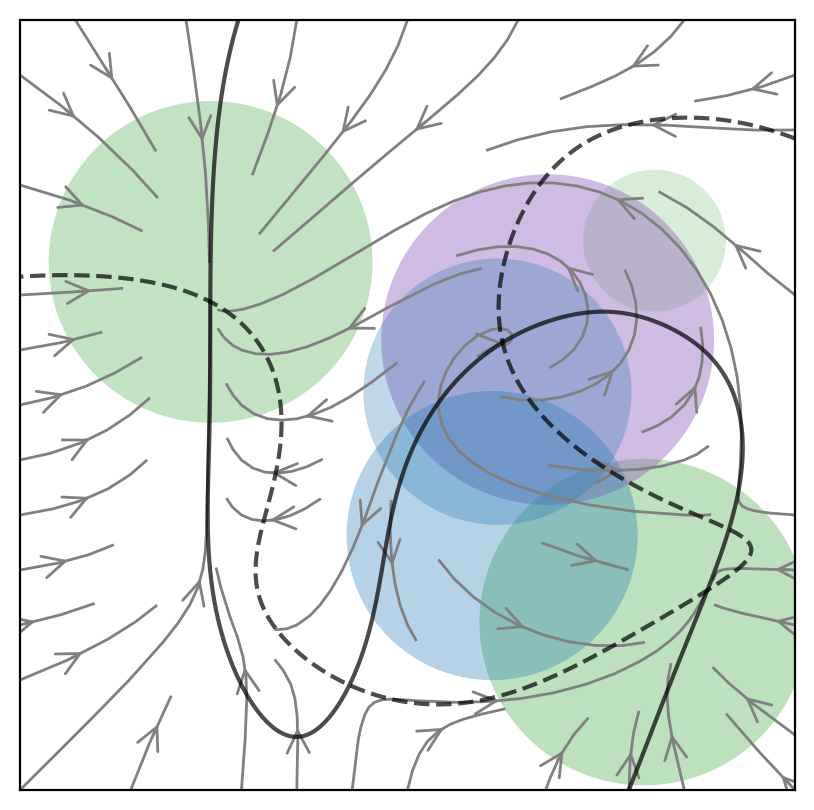

7.0


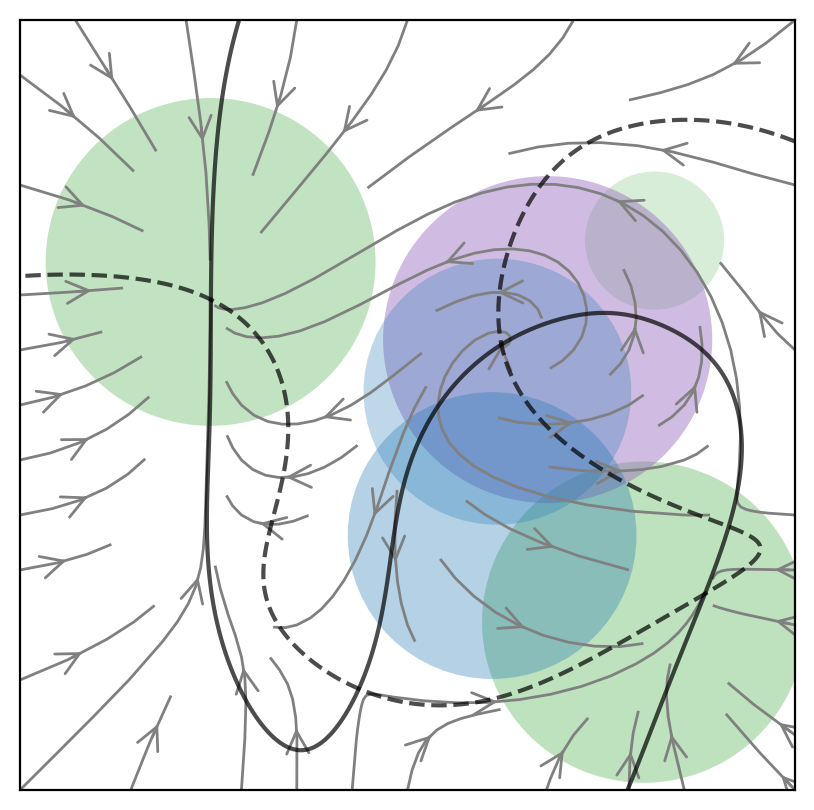

7.5


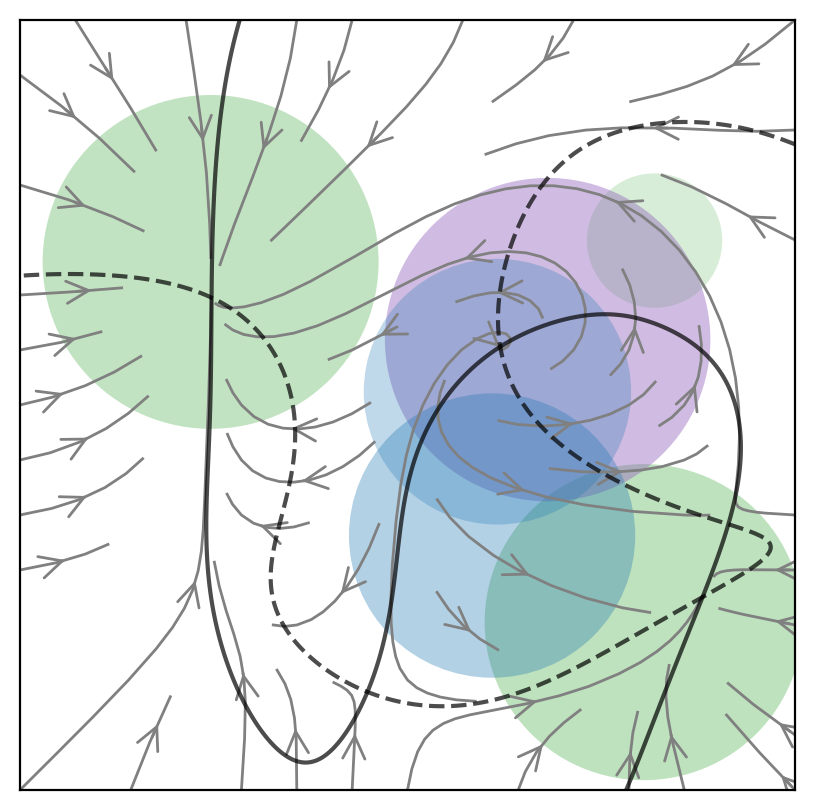

8.0


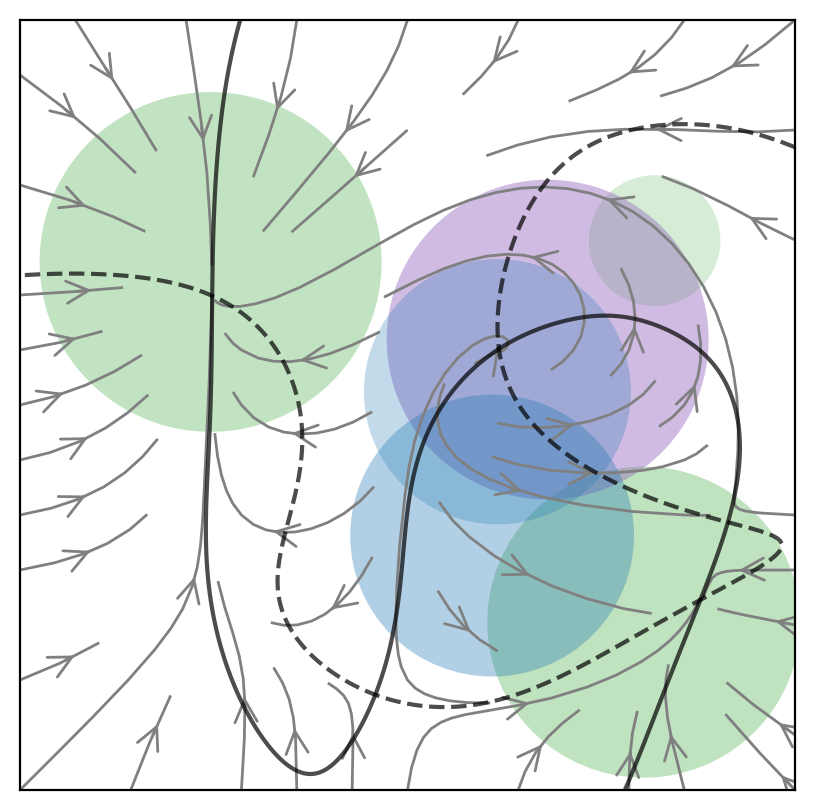

8.5


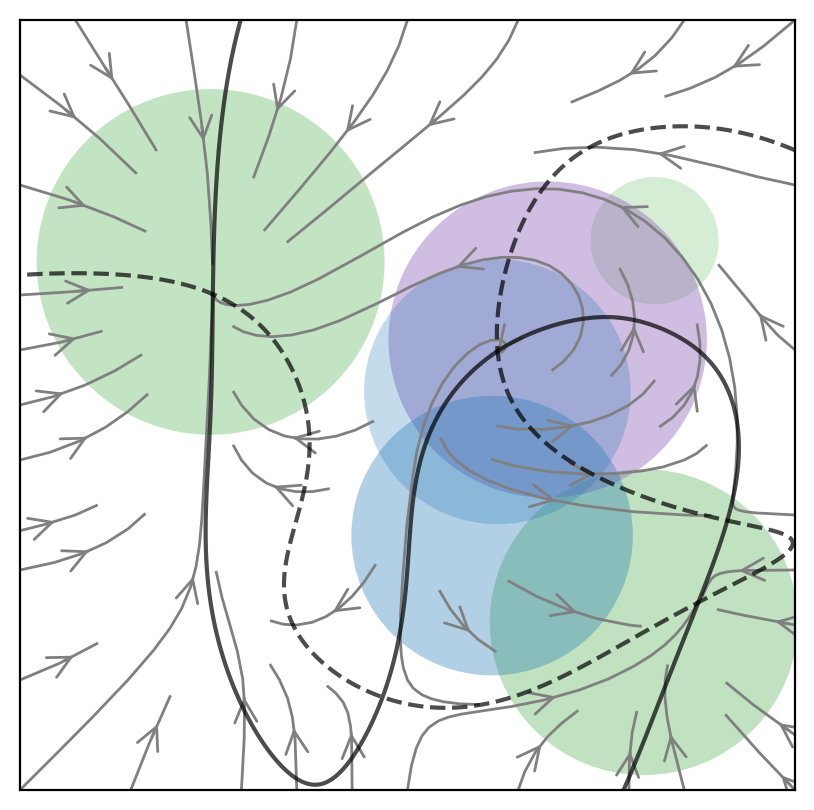

9.0


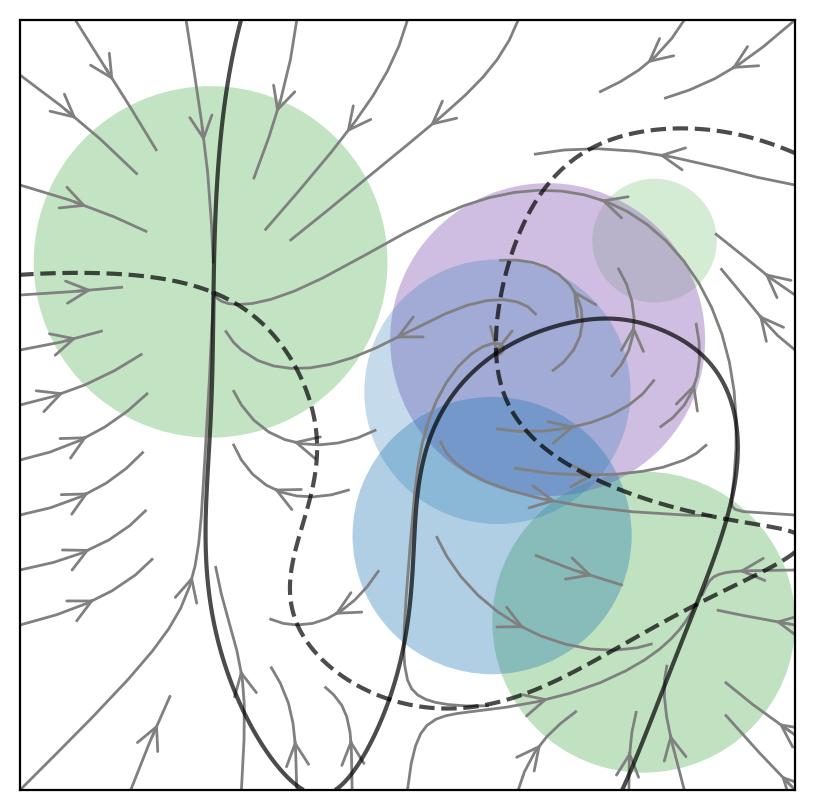

9.5


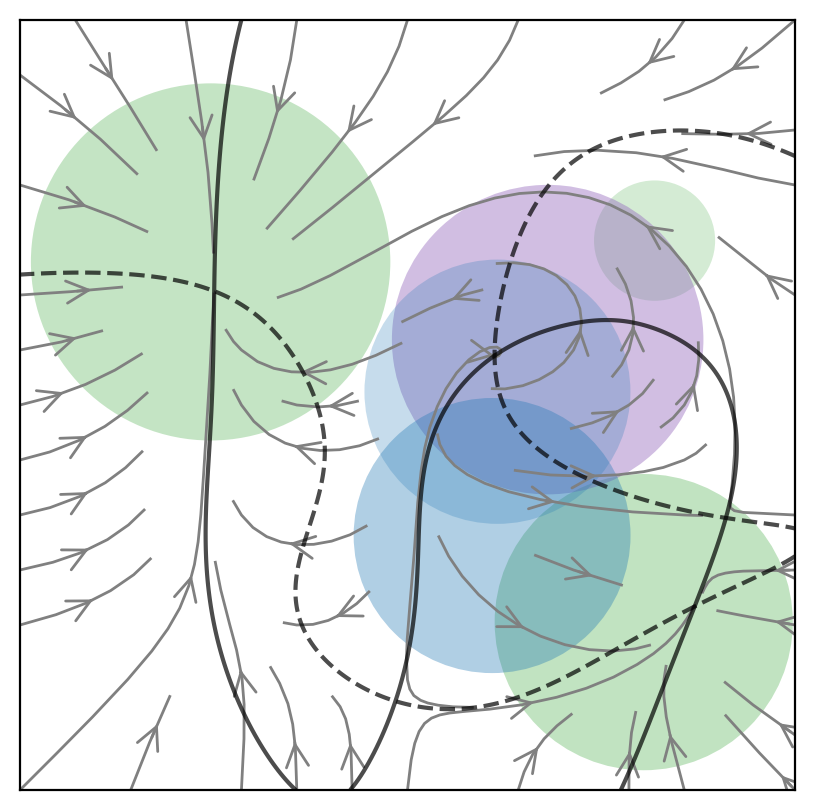

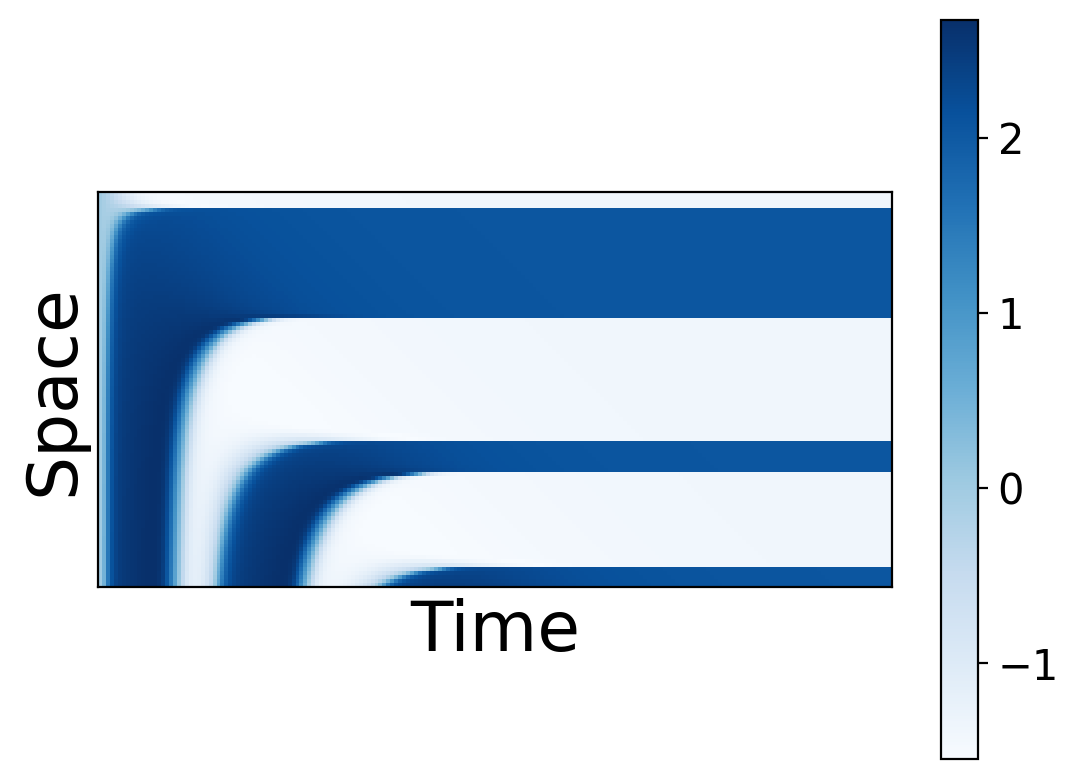

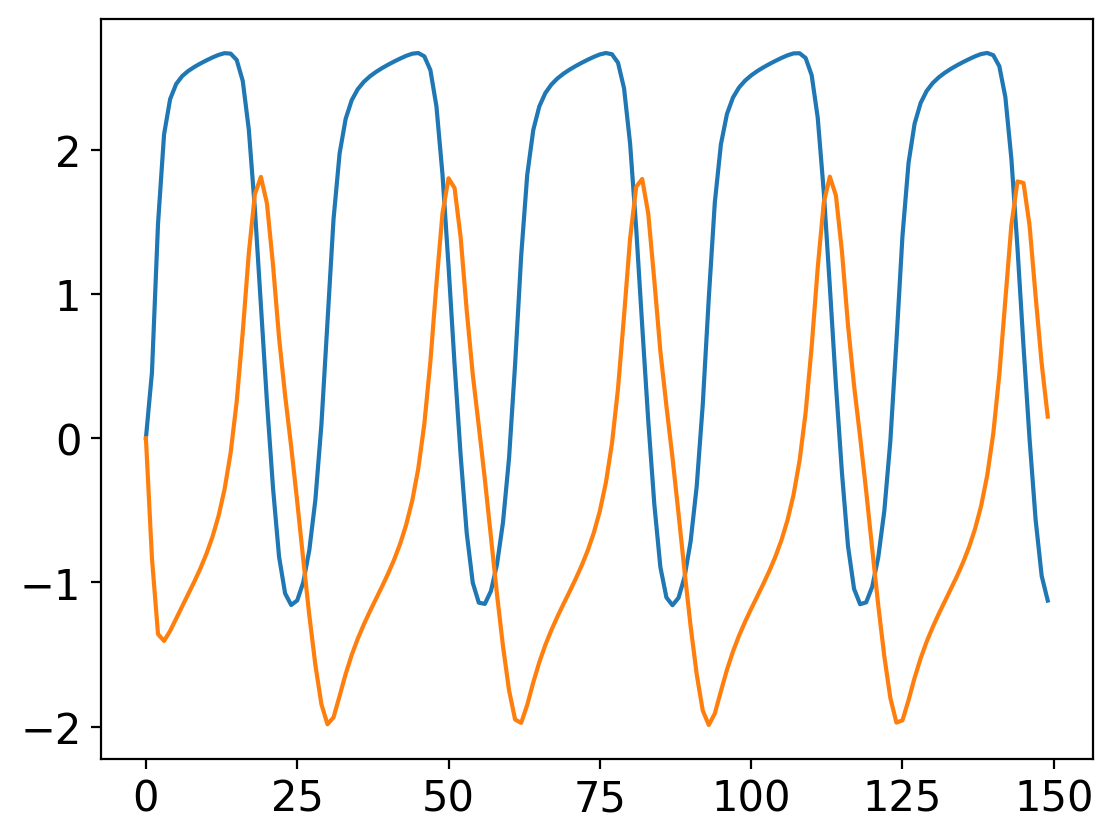

In [651]:
%autoreload

timecode = timecodes[2]
landscape = landscape_from_timecode(Somitogenesis_Landscape, timecode, data_dir, gen, landscape_pars)

inverted_landscape = invert_landscape(landscape)
print(landscape)
figure_from_timecode(timecode, data_dir, 'kymograph')


L = 3.
npoints = 301
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

# landscape = Somitogenesis_Landscape(module_list, regime=mr.mr_sigmoid, morphogen_times=(0.,), A0=0.005)

zlim=(-3, 1)
start = 0
init_cond = (-0., -0.)
# init_cond = ((-0.8, 1.5), (-1, 0.3), (-0.9, 0.))

times = (0, 30, 301)

t_a = -6.5
for it, t in enumerate(np.arange(t_a, t_a+10, 0.5)):
    print(it*0.5)
    fig = visualize_landscape_t(landscape, xx, yy, t=t, color_scheme='fp_types', traj_times=None, traj_init_cond=(0., 0.),
                                traj_start=start)
    # fig = visualize_landscape_t(landscape, xx, yy, t=t, color_scheme='fp_types', traj_times=None, traj_init_cond=None,
    #                             traj_start=start[it])
    # fig = visualize_landscape_t(inverted_landscape, xx, yy, t=t, color_scheme='fp_types', traj_times=times, traj_init_cond=(-2, 2.), traj_start=start)
    # fig = visualize_potential(landscape, xx, yy, t=t, elev=40, azim=-100, color_scheme='fp_types', scatter=True, cmap_center=0, zlim=zlim, rot_contour=True)

    plt.show()

landscape.get_fitness(fitness_pars)
plt.imshow(landscape.result[0][:, :], cmap='Blues')
plt.xlabel('Time', fontsize=25)
plt.ylabel('Space', fontsize=25)
plt.xticks(())
plt.yticks(())
plt.colorbar()
plt.show()
#
# plt.imshow(landscape.result[1][:, :], cmap='Blues')
# plt.xlabel('Time', fontsize=25)
# plt.ylabel('Space', fontsize=25)
# plt.xticks(())
# plt.yticks(())
# plt.show()


# landscape.morphogen_times = (50.,)

landscape.init_cells(1, (0., 0.,), 0.)

frozen_traj, states = landscape.run_cells(*time_pars, noise=0., ndt=fitness_pars['ndt'], get_states=False, frozen=True,
                                           t_freeze=-20.)

plt.plot(frozen_traj[0,0,:150])
plt.plot(frozen_traj[1,0,:150])


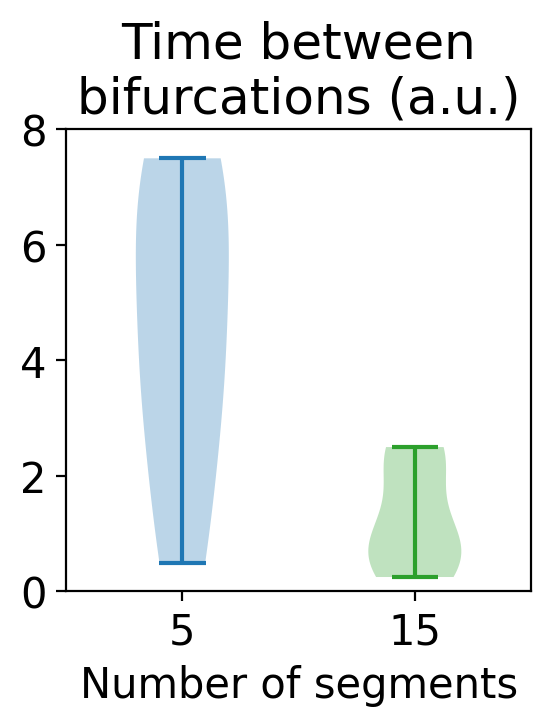

In [652]:
fig, ax = plt.subplots(1, 1, figsize=[3, 3])
delta_ap_5 = (7.5, 4.5, 3.5, 0.5, 7.5, 6., 3.5, 6.5, 1.5)
delta_ap_15 = (2, 2.5, 0.5, 0.5, 0.25, 1, 2.5, 1)
plt.violinplot((delta_ap_5,), positions=(5,), widths=4.)
plt.violinplot((delta_ap_5, ), positions=(-15,), widths=4.)
plt.violinplot((delta_ap_15,), positions=(15,), widths=4.)
plt.xticks((5,15))
plt.xlim((0, 20))
plt.ylim((0, 8))
plt.title('Time between\nbifurcations (a.u.)')
plt.xlabel('Number of segments')
plt.show()